<a href="https://colab.research.google.com/github/EnricoLB/Batara-cinerea-workflow/blob/main/BirdNET_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning
Adapted from "Intro to Cons. Bioacoustics 2024 -- November 14th, 2024"

Irina Tolkova --
K. Lisa Yang Center for Conservation Bioacoustics, Cornell University

Contact: itolkova@cornell.edu


---
Goal is to perform **dimensionality reduction and visualization** on recordings, to evaluate whether vocalizations can be used to distinguish subspecies.


## Imports and Functions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import signal
import soundfile as sf
import librosa

The functions below are used throughout the notebook. You don't need to modify anything here.

In [ ]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    cutoff = 2 * np.array([lowcut, highcut]) / fs
    b, a = signal.butter(order, cutoff, btype='band', analog=False)
    y = signal.filtfilt(b, a, data)
    return y

def butter_highpass_filter(data, cut, fs, order=5):
    cutoff = 2 * cut / fs
    b, a = signal.butter(order, cutoff, btype='high', analog=False)
    y = signal.filtfilt(b, a, data)
    return y

def butter_lowpass_filter(data, cut, fs, order=5):
    cutoff = 2 * cut / fs
    b, a = signal.butter(order, cutoff, btype='low', analog=False)
    y = signal.filtfilt(b, a, data)
    return y

def logTransform(spec, scale=10**(-5)):
    return 20 * np.log10(spec + scale * np.ones(spec.shape))

In [ ]:
def standardize3Sec(y, sr):
    if (len(y)/sr > 3):
        y = y[0:int(3 * sr)]
    else:
        y = np.hstack((y, np.zeros(int(3 * sr) - len(y))))

    return y

In [ ]:
def scaleAmplitude(y):
    return y/np.max(np.abs(y))

def spectralSubtraction(spec, noise_spectrum):
    phase = np.angle(spec)
    magnitude = np.abs(spec)
    magnitude = np.maximum(magnitude.T - noise_spectrum, 0).T
    magnitude = np.maximum(magnitude - np.mean(magnitude, axis=0), 0)
    magnitude = np.maximum(magnitude.T - np.mean(magnitude, axis=1), 0).T

    new_spec = np.empty(shape=spec.shape, dtype=np.complex128)
    new_spec.real = magnitude * np.cos(phase)
    new_spec.imag = magnitude * np.sin(phase)
    return new_spec

def audioFromSpec(spec, original_nf, i_cutoff_min, i_cutoff_max):
    # convert spectrogram back to audio
    full_spec = np.zeros((original_nf, spec.shape[1]), dtype=np.complex128)
    full_spec[i_cutoff_min:i_cutoff_max, :] = spec

# change according to frequencies
    _, s = signal.istft(full_spec, fs=48000, nperseg=1024)
    s = butter_bandpass_filter(s, 150, 8000, 48000, order=5)
    return s

In [ ]:
def spectrogram(call, sr, nperseg=1024):
    # filter signal, normalize slightly, crop or lengthen to 3 sec, and resave with a higher sampling rate
    call = call[int(sr * 0.3):-int(sr * 0.3)]
    call = call - np.mean(call)

    # calculate spectrogram
    freqs, inds, spec = signal.stft(call, fs=sr, nperseg=nperseg)
    original_nf = len(freqs)

    freq_cutoff_max = 8000
    freq_cutoff_min = 150
    i_cutoff_max = np.where(freqs > freq_cutoff_max)[0][0]
    i_cutoff_min = np.where(freqs <= freq_cutoff_min)[0][0]

    spec = spec[i_cutoff_min:i_cutoff_max,:]
    freqs = freqs[i_cutoff_min:i_cutoff_max]

    return freqs, inds, spec, original_nf, i_cutoff_min, i_cutoff_max

Now, you should see a collection of folders in Colab's "Files" section. The *Audio* folder contains our original dataset of upcalls, labeled by individual ("a", "b", "c"), day (2019-05-01), and a numerical index. Focus on this one for now; we will get to the other folders.

In [ ]:
# set the filename and load in the call
filename = '/content/drive/MyDrive/Mestrado/Projeto Batara/Artigo Batara/BirdNET/Audio/0_cin.wav'
signal_call, sr = librosa.load(filename, sr=None)

In [ ]:
# make a spectrogram of this call
freqs, inds, spec, original_nf, i_cutoff_min, i_cutoff_max = spectrogram(signal_call, sr)

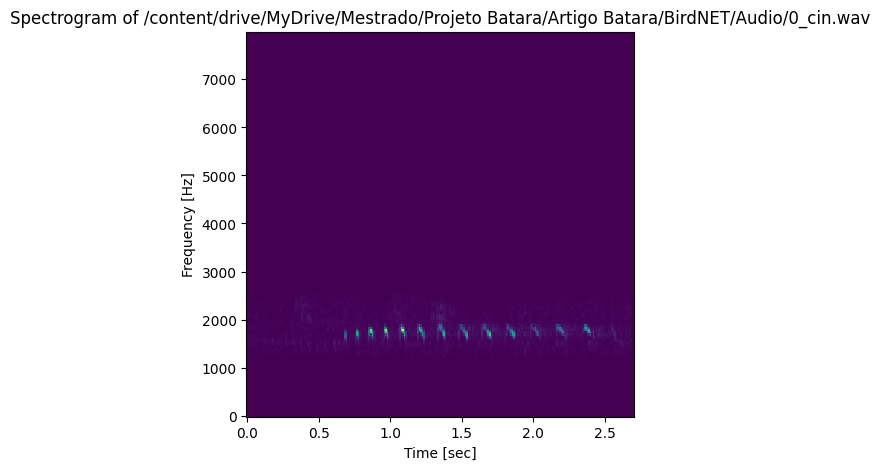

In [ ]:
# plot the spectrogram
plt.figure(figsize=(5, 5))
plt.pcolormesh(inds, freqs, np.abs(spec))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram of %s' % filename)
plt.show()

ValueError: num must be an integer with 1 <= num <= 36, not 37

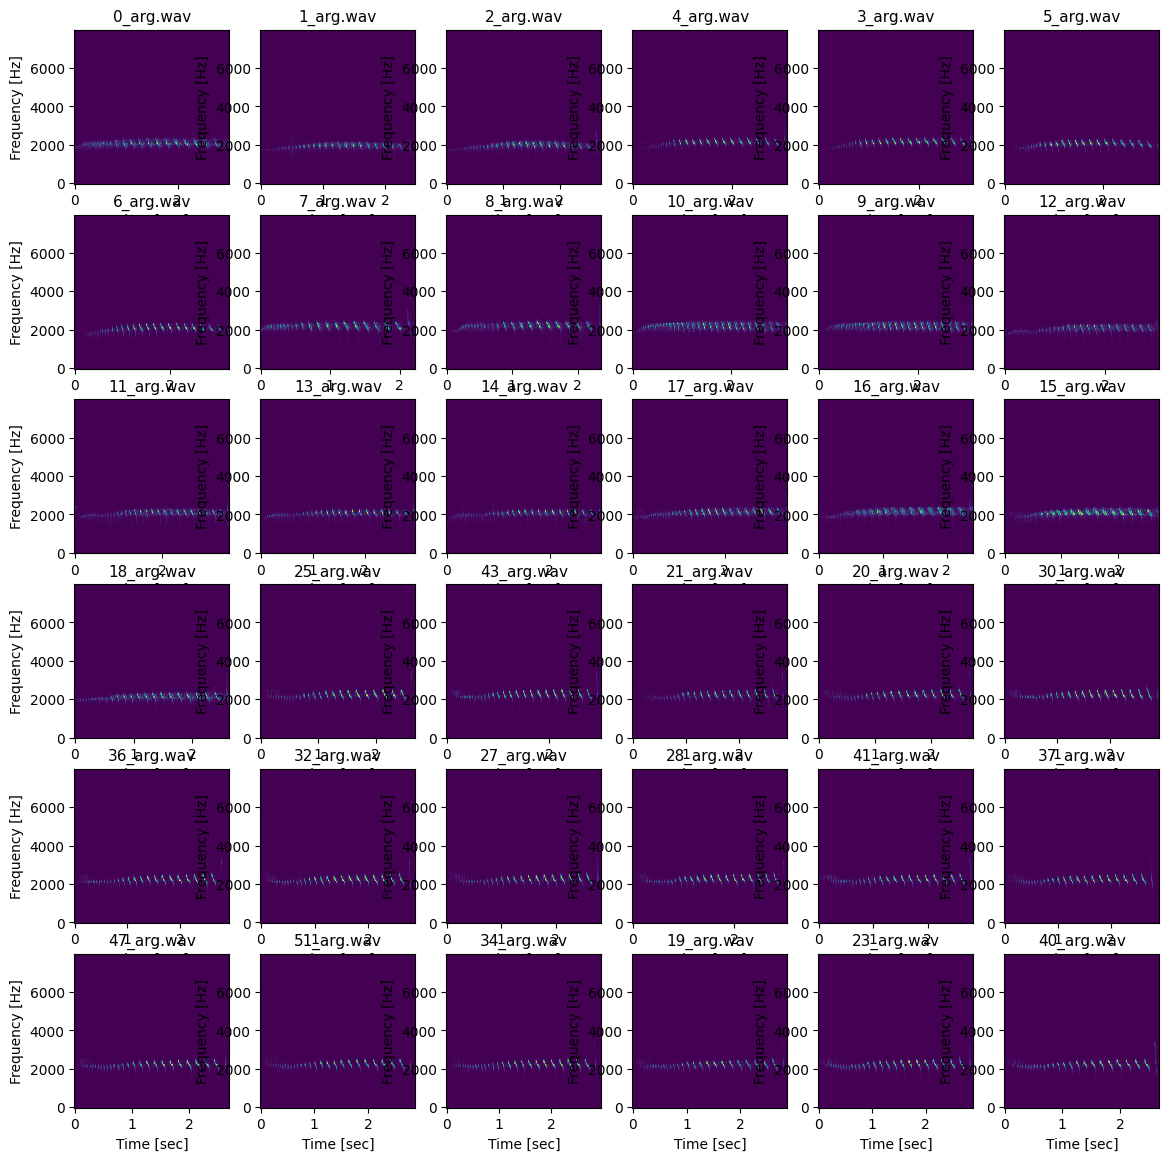

In [ ]:
# set the filename and load in the call
call_files = [f for f in os.listdir('/content/drive/MyDrive/Mestrado/Projeto Batara/Artigo Batara/BirdNET/Audio/') if '.wav' in f]

plt.figure(figsize=(14, 14))
for i, filename in enumerate(call_files):
    signal_call, sr = librosa.load('/content/drive/MyDrive/Mestrado/Projeto Batara/Artigo Batara/BirdNET/Audio/' + filename, sr=None)

    # make a spectrogram of this call
    freqs, inds, spec, original_nf, i_cutoff_min, i_cutoff_max = spectrogram(signal_call, sr)

    # plot the spectrogram
    plt.subplot(6, 6, i+1)
    plt.pcolormesh(inds, freqs, np.abs(spec))
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.title(filename, fontsize=11)

plt.tight_layout()

## Dimensionality Reduction and Visualization

While the BirdNET embeddings are a way of extracting features and reducing dimensionality from spectrograms or audio, they still have a lot of numbers, which is difficult to visualize. How can we reduce this to 2 numbers?

**Let's try using UMAP to turn the embeddings into a 2D representation that preserves the similarities and structure of the dataset!**

The UMAP implementation in Python is not part of the standard libraries included with Python, so we will install it below:

In [ ]:
!pip install umap-learn

In [ ]:
# import umap!
import umap

# also import some more plotting tools
import matplotlib as mpl
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [ ]:
## --- This function reads all of the embeddings from a particular folder and stacks them into a large matrix. --- ##

def readEmbeddings(folder):
    embeddings = []
    labels = []
    filenames = []
    audio_filenames = []
    call_indicator = []
    nametags = []

    files = os.listdir(folder)

    files = [f for f in files if f[-4:] == '.txt']

 # iterate through all files
    for file in files:
        em = pd.read_csv(folder + file, header=None)
        em.iloc[0, 0] = em.iloc[0, 0].split('\t')[2]
        embeddings.append(em.iloc[0,:])

        # Modified line to extract labels:
        labels.append(file.split('.')[0].split('_')[1])


        filenames.append(folder + '/' + file)
        audiofile = file.replace('.birdnet.embeddings.txt', '.wav')
        audio_filenames.append(audiofile)
        call_indicator.append(any(x in file for x in ['cin', 'arg', 'exc']))
        nametags.append(file[0:17])

    embeddings = np.squeeze(np.array(embeddings))
    call_indicator = np.array(call_indicator)
    labels = np.array(labels)
    nametags = np.array(nametags)

    return embeddings, call_indicator, labels, nametags, filenames, audio_filenames

Choose a folder:

In [ ]:
folder = '/content/drive/MyDrive/Mestrado/Projeto Batara/Artigo Batara/BirdNET/embeddings/all/'

In [ ]:
embeddings_folder = '/content/drive/MyDrive/Mestrado/Projeto Batara/Artigo Batara/BirdNET/embeddings/all/'
audio_folder = '/content/drive/MyDrive/Mestrado/Projeto Batara/Artigo Batara/BirdNET/Audio/'

Read in the embeddings from this folder:

In [ ]:
embeddings, call_indicator, labels, nametags, filenames, audio_filenames = readEmbeddings(embeddings_folder)

Check if the labels match the population names used in the files (in this case, should be 'cin', 'arg' and 'exc'):

In [ ]:
labels

array(['arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg', 'arg',
       'arg', 'arg',

Prepare some variables for plotting:

In [ ]:
unique_labels = np.unique(labels)
colors = {'cin': 'darkorange', 'arg': 'springgreen', 'exc': 'navy'}
styles = {'cin': 'o', 'arg': 'x', 'exc': 'v'}

### UMAP projection for just loudsongs:

Let's calculate the 2D projection for all of the loudsongs:

In [ ]:
um = umap.UMAP(n_components=3)
umap_points = um.fit_transform(embeddings[call_indicator])

What does the distribution of these points look like?

Text(0.5, 1.0, 'Populations UMAP')

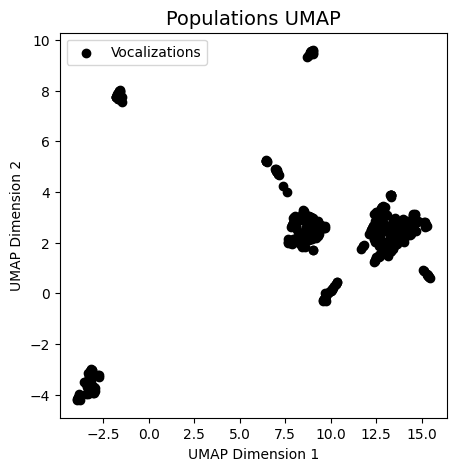

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plt.scatter(umap_points[:, 0], umap_points[:, 1], c='k', marker='o', label='Vocalizations')
plt.legend()
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('Populations UMAP', fontsize=14)

In this project, we know that different upcalls were produced by different whales. So let's **format the scatterplot to show different individuals**:

Text(0.5, 1.0, 'Upcall UMAP')

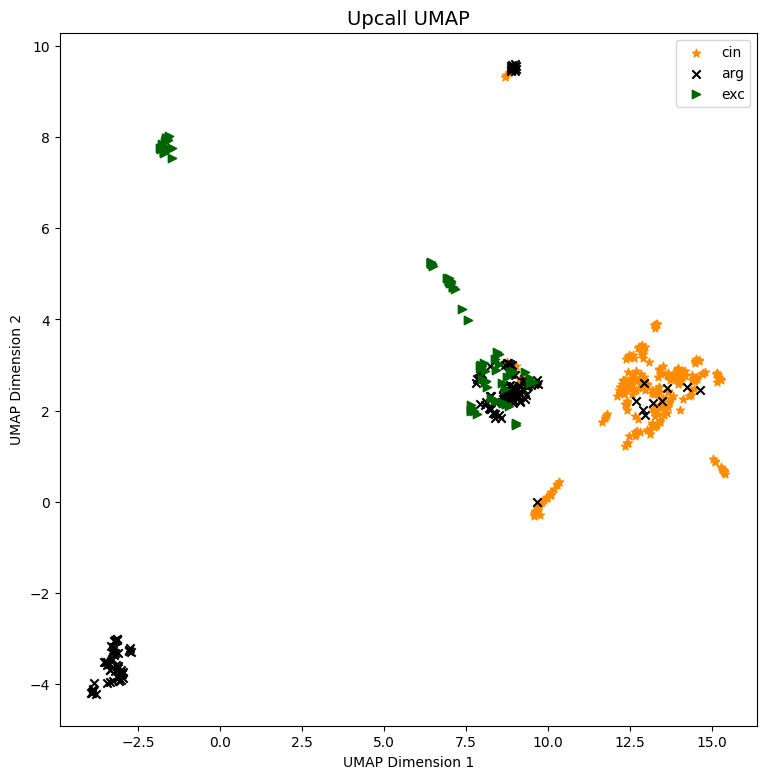

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
plt.scatter(umap_points[labels[call_indicator]=='cin', 0], umap_points[labels[call_indicator]=='cin', 1], c='darkorange', marker='*', label='cin')
plt.scatter(umap_points[labels[call_indicator]=='arg', 0], umap_points[labels[call_indicator]=='arg', 1], c='black', marker='x', label='arg')
plt.scatter(umap_points[labels[call_indicator]=='exc', 0], umap_points[labels[call_indicator]=='exc', 1], c='darkgreen', marker='>', label='exc')
plt.legend()
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('Upcall UMAP', fontsize=14)

# Aqui

Text(0.5, 0.92, 'Upcall UMAP')

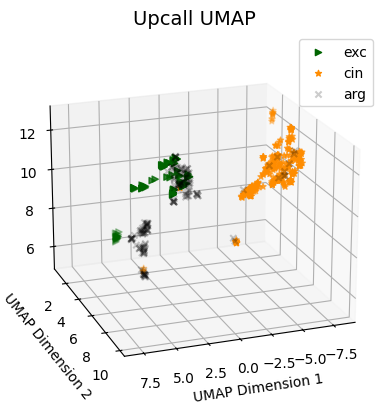

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# 'exc' with zorder=2 (drawn in the middle)
ax.scatter(umap_points[labels[call_indicator]=='exc', 0], umap_points[labels[call_indicator]=='exc', 1], umap_points[labels[call_indicator]=='exc', 2], c='darkgreen', marker='>', label='exc', zorder=2)

# 'cin' with zorder=3 (drawn on top)
ax.scatter(umap_points[labels[call_indicator]=='cin', 0], umap_points[labels[call_indicator]=='cin', 1], umap_points[labels[call_indicator]=='cin', 2], c='darkorange', marker='*', label='cin', zorder=3)

# 'arg' with zorder=1 (drawn behind) and transparency
ax.scatter(umap_points[labels[call_indicator]=='arg', 0], umap_points[labels[call_indicator]=='arg', 1], umap_points[labels[call_indicator]=='arg', 2], c='black', marker='x', label='arg', alpha=0.2, zorder=1)
ax.view_init(elev=20, azim=70)
plt.legend()
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('Upcall UMAP', fontsize=14)

> ❓ **What do you observe in this figure? What conclusions might you make from it?**

Each of these points represents an upcall. Let's try to plot the upcall spectrograms in the same places as these UMAP dots, for a more intuitive representation of dimensionality reduction.

In [ ]:
def drawPlot(embeddings, specs, labels, call_indicator):
    um = umap.UMAP(n_components=2)
    umap_points = um.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(umap_points[:, 0], umap_points[:, 1])

    for l in unique_labels:
        ax.scatter(umap_points[0, 0], umap_points[0, 1], c=colors[l], label=l)

    for i in range(umap_points.shape[0]):
        img = np.reshape(specs[i], spec.shape)
        if not call_indicator[i]:
            img = img[:,0:spec.shape[1]//2]

        img[img < -80] = -80
        img[img > 0] = 0
        ab = AnnotationBbox(OffsetImage(np.flipud(img.astype(float)), zoom=0.4), (umap_points[i, 0], umap_points[i, 1]),
                            frameon=True, bboxprops = dict(edgecolor=colors[labels[i]], linewidth=2))
        ax.add_artist(ab)
        #ax.scatter(umap_points[i, 0], umap_points[i, 1], c=colors[labels[i]])

    plt.xlabel('UMAP Dimension 1', fontsize=14)
    plt.ylabel('UMAP Dimension 2', fontsize=14)
    plt.legend(fontsize=12)
    plt.tight_layout()

In [ ]:
#0_arg.birdnet.embeddings.txt // 0_arg.wav

In [ ]:
audio_filenames

['6_exc.wav',
 '7_exc.wav',
 '3_exc.wav',
 '0_exc.wav',
 '2_exc.wav',
 '4_exc.wav',
 '1_exc.wav',
 '9_exc.wav',
 '8_exc.wav',
 '5_exc.wav',
 '47_exc.wav',
 '46_exc.wav',
 '40_exc.wav',
 '42_exc.wav',
 '41_exc.wav',
 '44_exc.wav',
 '43_exc.wav',
 '55_exc.wav',
 '49_exc.wav',
 '48_exc.wav',
 '16_exc.wav',
 '18_exc.wav',
 '17_exc.wav',
 '12_exc.wav',
 '13_exc.wav',
 '10_exc.wav',
 '15_exc.wav',
 '11_exc.wav',
 '14_exc.wav',
 '19_exc.wav',
 '36_exc.wav',
 '33_exc.wav',
 '37_exc.wav',
 '34_exc.wav',
 '35_exc.wav',
 '31_exc.wav',
 '30_exc.wav',
 '45_exc.wav',
 '39_exc.wav',
 '38_exc.wav',
 '27_exc.wav',
 '26_exc.wav',
 '24_exc.wav',
 '25_exc.wav',
 '21_exc.wav',
 '22_exc.wav',
 '20_exc.wav',
 '32_exc.wav',
 '29_exc.wav',
 '28_exc.wav',
 '23_exc.wav',
 '25_cin.wav',
 '24_cin.wav',
 '21_cin.wav',
 '15_cin.wav',
 '13_cin.wav',
 '12_cin.wav',
 '8_cin.wav',
 '10_cin.wav',
 '7_cin.wav',
 '6_cin.wav',
 '9_cin.wav',
 '58_exc.wav',
 '56_exc.wav',
 '51_exc.wav',
 '57_exc.wav',
 '54_exc.wav',
 '52_exc.

In [ ]:
# first, calculate spectrograms:

specs = []
for i, file in enumerate(audio_filenames):
    call, sr = librosa.load(audio_folder + file, sr=None)
    call = standardize3Sec(call, sr)
    freqs, inds, spec = signal.stft(call, fs=sr, nperseg=256)
    spec = logTransform(np.abs(spec[0:60,:]))
    specs.append(spec.ravel())

specs = np.array(specs)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-77-87c7658d8c6e>:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
<ipython-input-79-3bd4560d98a6>:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


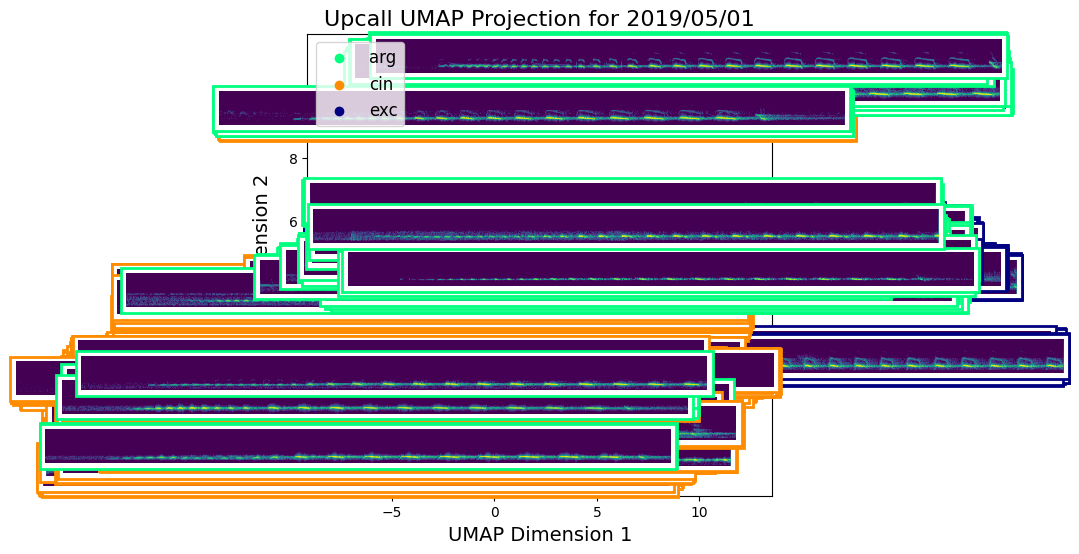

In [ ]:
drawPlot(embeddings[call_indicator], specs[call_indicator], labels[call_indicator], call_indicator[call_indicator])
plt.title('Upcall UMAP Projection for 2019/05/01', fontsize=16)
plt.tight_layout()

# SVM classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

This cell imports the necessary libraries for building and evaluating the SVM and Dummy classifiers.

- `SVC` is the Support Vector Classifier class.
- `DummyClassifier` is used to create a baseline classifier for comparison.
- `train_test_split` is used to split the data into training and testing sets.
- `accuracy_score` and `classification_report` are used to evaluate the performance of the classifiers.

In [ ]:
# Assuming 'embeddings' and 'labels' are already loaded
# from the previous code.
X = embeddings[call_indicator]
y = labels[call_indicator]

- `X` is assigned the embeddings that correspond to the vocalizations of interest (indicated by `call_indicator`). This will be the input to the classifiers.

- `y` is assigned the corresponding labels for these vocalizations. This is what the classifiers will try to predict.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This cell splits the data into training and testing sets using `train_test_split`.

- `test_size=0.2` means that 20% of the data will be used for testing, and the remaining 80% for training.
- `random_state=42` ensures that the split is reproducible, meaning you'll get the same split every time you run the code.

In [ ]:
svm_classifier = SVC(kernel='linear')  # You can experiment with different kernels
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear')

This cell initializes and trains the SVM classifier.

- `SVC(kernel='linear')` creates an SVM classifier with a linear kernel. You can explore other kernels like 'rbf' or 'poly'.
- `fit(X_train, y_train)` trains the classifier using the training data.

In [ ]:
svm_predictions = svm_classifier.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"SVM Accuracy: {svm_accuracy}")
print("SVM Classification Report:\n", classification_report(y_test, svm_predictions))

SVM Accuracy: 0.99
SVM Classification Report:
               precision    recall  f1-score   support

         arg       0.96      1.00      0.98        26
         cin       1.00      1.00      1.00        51
         exc       1.00      0.96      0.98        23

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



This cell uses the trained SVM classifier to make predictions on the test data and then evaluates its performance.

- `predict(X_test)` generates predictions for the test data.
- `accuracy_score` calculates the accuracy of the predictions.
- `classification_report` provides a more detailed report on precision, recall, F1-score, and support for each class.

In [ ]:
dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(X_train, y_train)

dummy_predictions = dummy_classifier.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_predictions)
print(f"\nDummy Classifier Accuracy: {dummy_accuracy}")
print("Dummy Classifier Classification Report:\n", classification_report(y_test, dummy_predictions))


Dummy Classifier Accuracy: 0.51
Dummy Classifier Classification Report:
               precision    recall  f1-score   support

         arg       0.00      0.00      0.00        26
         cin       0.51      1.00      0.68        51
         exc       0.00      0.00      0.00        23

    accuracy                           0.51       100
   macro avg       0.17      0.33      0.23       100
weighted avg       0.26      0.51      0.34       100



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This cell does the same as Cell 5 but for the Dummy Classifier. This provides a baseline performance to compare the SVM classifier against. The `strategy="most_frequent"` means the Dummy Classifier will always predict the most frequent class in the training data.

SVM Accuracy: 0.99
SVM Classification Report:
               precision    recall  f1-score   support

         arg       0.96      1.00      0.98        26
         cin       1.00      1.00      1.00        51
         exc       1.00      0.96      0.98        23

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100


Dummy Classifier Accuracy: 0.51
Dummy Classifier Classification Report:
               precision    recall  f1-score   support

         arg       0.00      0.00      0.00        26
         cin       0.51      1.00      0.68        51
         exc       0.00      0.00      0.00        23

    accuracy                           0.51       100
   macro avg       0.17      0.33      0.23       100
weighted avg       0.26      0.51      0.34       100



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


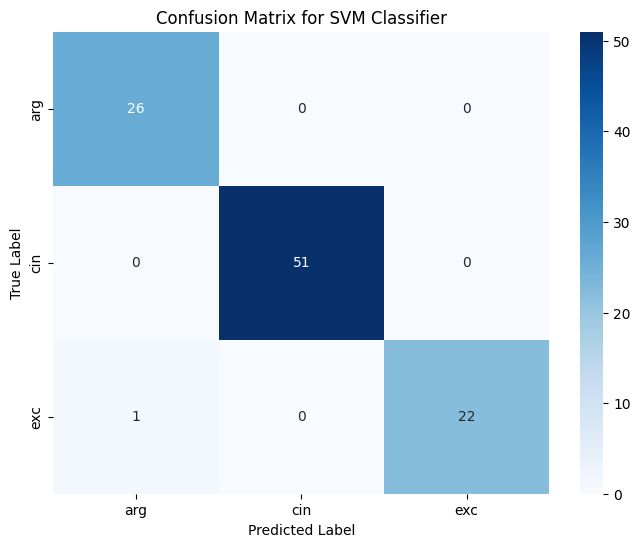

In [ ]:
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'embeddings' and 'labels' are already loaded
# from the previous code.
X = embeddings[call_indicator]
y = labels[call_indicator]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train an SVM classifier
svm_classifier = SVC(kernel='linear')  # You can experiment with different kernels
svm_classifier.fit(X_train, y_train)

# Make predictions
svm_predictions = svm_classifier.predict(X_test)

# Evaluate the SVM classifier
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"SVM Accuracy: {svm_accuracy}")
print("SVM Classification Report:\n", classification_report(y_test, svm_predictions))

# Initialize and train a Dummy Classifier (for comparison)
dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(X_train, y_train)

# Make predictions with the dummy classifier
dummy_predictions = dummy_classifier.predict(X_test)

# Evaluate the Dummy Classifier
dummy_accuracy = accuracy_score(y_test, dummy_predictions)
print(f"\nDummy Classifier Accuracy: {dummy_accuracy}")
print("Dummy Classifier Classification Report:\n", classification_report(y_test, dummy_predictions))

# Create and display confusion matrix for SVM
cm = confusion_matrix(y_test, svm_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=svm_classifier.classes_,
            yticklabels=svm_classifier.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for SVM Classifier")
plt.show()